# eBay Perfume Market Intelligence
### Decoding Consumer Behavior & Revenue Drivers in the Online Fragrance Market

---

> **Project Type:** Exploratory Data Analysis | Business Intelligence  
> **Domain:** E-Commerce · Retail Analytics · Consumer Behavior  
> **Dataset:** eBay Men's & Women's Perfume Sales (1,000 listings each)  
> **Tools:** Python · Pandas · Matplotlib · Seaborn  


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ── Visual Style ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.1)
PALETTE_M = '#2563EB'   # Blue — Men's
PALETTE_W = '#DB2777'   # Pink — Women's
PALETTE_DUAL = [PALETTE_M, PALETTE_W]

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white'
})

print("Libraries loaded successfully.")


Libraries loaded successfully.


In [2]:
# ── Load datasets ─────────────────────────────────────────────────────────────
men   = pd.read_csv('ebay_mens_perfume.csv')
women = pd.read_csv('ebay_womens_perfume.csv')

print(f"Men's dataset  : {men.shape[0]:,} rows × {men.shape[1]} columns")
print(f"Women's dataset: {women.shape[0]:,} rows × {women.shape[1]} columns")
print("\nColumn overview:")
print(men.dtypes)


Men's dataset  : 1,000 rows × 10 columns
Women's dataset: 1,000 rows × 10 columns

Column overview:
brand                 object
title                 object
type                  object
price                float64
priceWithCurrency     object
available            float64
availableText         object
sold                 float64
lastUpdated           object
itemLocation          object
dtype: object


In [3]:
men.head()


,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation
0,Dior,Christian Dior Sauvage Men's EDP 3.4 oz Fragra...,Eau de Parfum,84.99,US $84.99/ea,10.0,More than 10 available / 116 sold,116.0,"May 24, 2024 10:03:04 PDT","Allen Park, Michigan, United States"
1,AS SHOW,A-v-entus Eau de Parfum 3.3 oz 100ML Millesime...,Eau de Parfum,109.99,US $109.99,8.0,8 available / 48 sold,48.0,"May 23, 2024 23:07:49 PDT","Atlanta, Georgia, Canada"
2,Unbranded,HOGO BOSS cologne For Men 3.4 oz,Eau de Toilette,100.00,US $100.00,10.0,More than 10 available / 27 sold,27.0,"May 22, 2024 21:55:43 PDT","Dearborn, Michigan, United States"
3,Giorgio Armani,Acqua Di Gio by Giorgio Armani 6.7 Fl oz Eau D...,Eau de Toilette,44.99,US $44.99/ea,2.0,2 available / 159 sold,159.0,"May 24, 2024 03:30:43 PDT","Reinholds, Pennsylvania, United States"
4,Lattafa,Lattafa Men's Hayaati Al Maleky EDP Spray 3.4 ...,Fragrances,16.91,US $16.91,NaN,Limited quantity available / 156 sold,156.0,"May 24, 2024 07:56:25 PDT","Brooklyn, New York, United States"


## 2. Data Cleaning & Feature Engineering

Before analysis, we handle:
- **Missing values** — using domain-aware imputation (not blind fills)
- **Type normalization** — fragrance type labels are inconsistent across listings
- **Feature engineering** — create `revenue`, `price_segment`, and clean `lastUpdated`


In [5]:
def clean_perfume_data(df, label='dataset'):
    """
    Applies consistent cleaning to a perfume sales DataFrame.
    Returns a cleaned copy with engineered features.
    """
    df = df.copy()

    # ── Missing values ─────────────────────────────────────────────────────────
    # 'available' NaN = out of stock (0 units remaining)
    df['available'] = df['available'].fillna(0)
    # 'sold' NaN = no recorded sales
    df['sold'] = df['sold'].fillna(0)
    # Unknown brand/type
    df['brand'] = df['brand'].fillna('Unknown')
    df['type']  = df['type'].fillna('Unknown')

    # ── Datetime ───────────────────────────────────────────────────────────────
    df['lastUpdated'] = pd.to_datetime(df['lastUpdated'], errors='coerce')
    df['lastUpdated'] = df['lastUpdated'].ffill().bfill()

    # ── Normalize fragrance type labels ───────────────────────────────────────
    # eBay sellers use inconsistent casing/spacing for the same type
    type_map = {
        'Eau De Parfum'         : 'Eau de Parfum',
        'Eau De Toilette'       : 'Eau de Toilette',
        'Eau de Perfume'        : 'Eau de Parfum',
        'Eau de Toilette, Spray': 'Eau de Toilette',
        'Fragrance Mist'        : 'Body Mist / Other',
        'Fragrances'            : 'Body Mist / Other',
        'Gift Sets'             : 'Gift Set',
    }
    df['type'] = df['type'].replace(type_map)

    # ── Feature Engineering ───────────────────────────────────────────────────
    # Revenue = proxy for total sales value (price × units sold)
    df['revenue'] = df['price'] * df['sold']

    # Price segmentation — based on USD market tiers
    df['price_segment'] = pd.cut(
        df['price'],
        bins=[0, 25, 60, 100, np.inf],
        labels=['Budget (<$25)', 'Mid-Range ($25–$60)',
                'Premium ($60–$100)', 'Luxury (>$100)']
    )

    # Location: extract country (last part after the final comma)
    df['country'] = df['itemLocation'].str.split(',').str[-1].str.strip()

    print(f"{label} cleaned. Shape: {df.shape} | Nulls remaining: {df.isnull().sum().sum()}")
    return df

men   = clean_perfume_data(men,   label="Men's")
women = clean_perfume_data(women, label="Women's")


Men's cleaned. Shape: (1000, 13) | Nulls remaining: 3
Women's cleaned. Shape: (1000, 13) | Nulls remaining: 8


## 3. Exploratory Analysis — Men's Perfume Segment

We examine the men's market across five lenses:
brand dominance, price distribution, fragrance type preference, revenue drivers, and supply-demand dynamics.


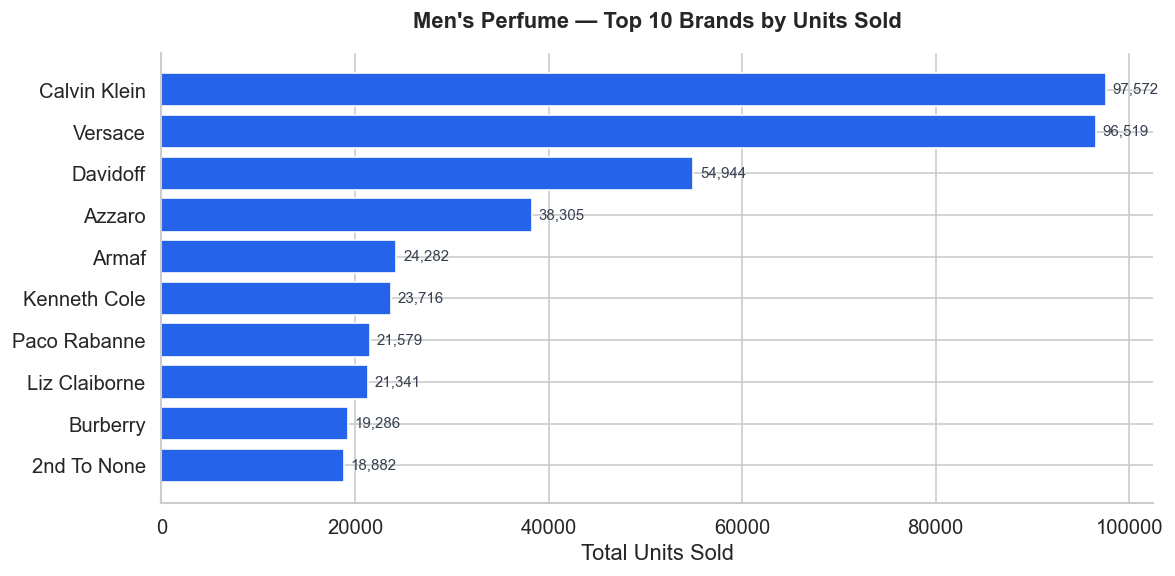


Top 5 Men's brands by units sold:
brand
Calvin Klein    97572.0
Versace         96519.0
Davidoff        54944.0
Azzaro          38305.0
Armaf           24282.0
Name: sold, dtype: float64


In [6]:
# ── 3.1 Brand Dominance ───────────────────────────────────────────────────────
top_brands_m = (
    men.groupby('brand')['sold']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_brands_m.index[::-1], top_brands_m.values[::-1], color=PALETTE_M, edgecolor='white')
ax.bar_label(bars, fmt='{:,.0f}', padding=4, fontsize=9, color='#374151')
ax.set_xlabel('Total Units Sold')
ax.set_title("Men's Perfume — Top 10 Brands by Units Sold", fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("\nTop 5 Men's brands by units sold:")
print(top_brands_m.head())


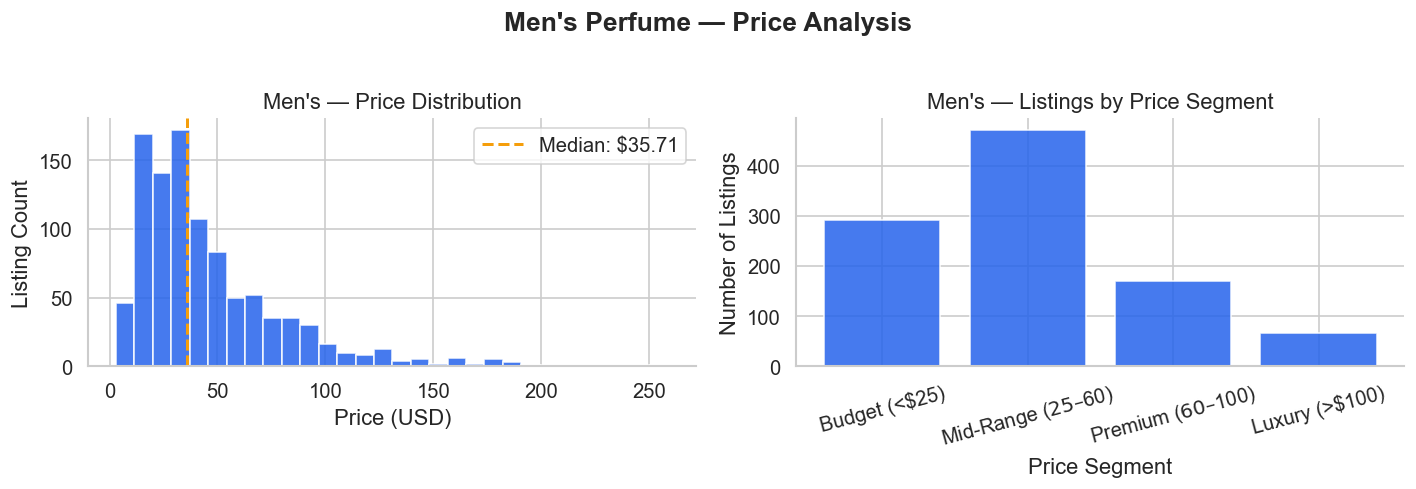

In [7]:
# ── 3.2 Price Distribution ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(men['price'], bins=30, color=PALETTE_M, edgecolor='white', alpha=0.85)
axes[0].axvline(men['price'].median(), color='#F59E0B', linestyle='--', linewidth=1.8, label=f"Median: ${men['price'].median():.2f}")
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Listing Count')
axes[0].set_title("Men's — Price Distribution")
axes[0].legend()

# Segment breakdown (count)
seg_count_m = men['price_segment'].value_counts().sort_index()
axes[1].bar(seg_count_m.index, seg_count_m.values, color=PALETTE_M, edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Price Segment')
axes[1].set_ylabel('Number of Listings')
axes[1].set_title("Men's — Listings by Price Segment")
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle("Men's Perfume — Price Analysis", fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


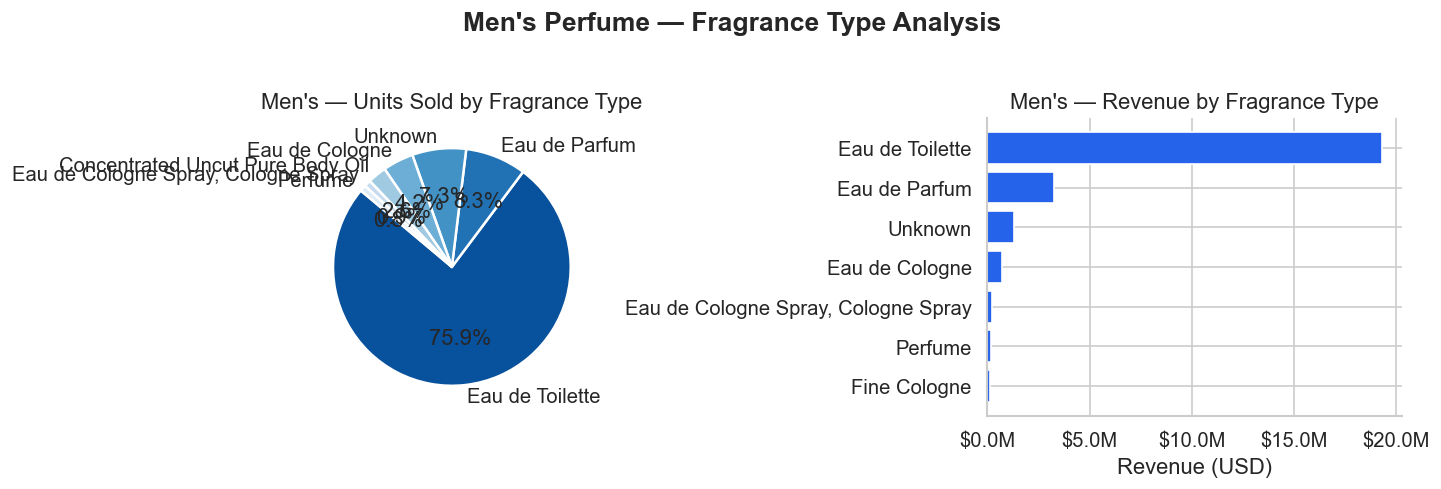

In [8]:
# ── 3.3 Fragrance Type Preference ────────────────────────────────────────────
type_sold_m = (
    men.groupby('type')['sold']
    .sum()
    .sort_values(ascending=False)
    .head(7)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].pie(type_sold_m.values, labels=type_sold_m.index,
            autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('Blues_r', len(type_sold_m)),
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[0].set_title("Men's — Units Sold by Fragrance Type")

# By revenue
type_rev_m = men.groupby('type')['revenue'].sum().sort_values(ascending=False).head(7)
axes[1].barh(type_rev_m.index[::-1], type_rev_m.values[::-1], color=PALETTE_M, edgecolor='white')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[1].set_title("Men's — Revenue by Fragrance Type")
axes[1].set_xlabel('Revenue (USD)')

plt.suptitle("Men's Perfume — Fragrance Type Analysis", fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


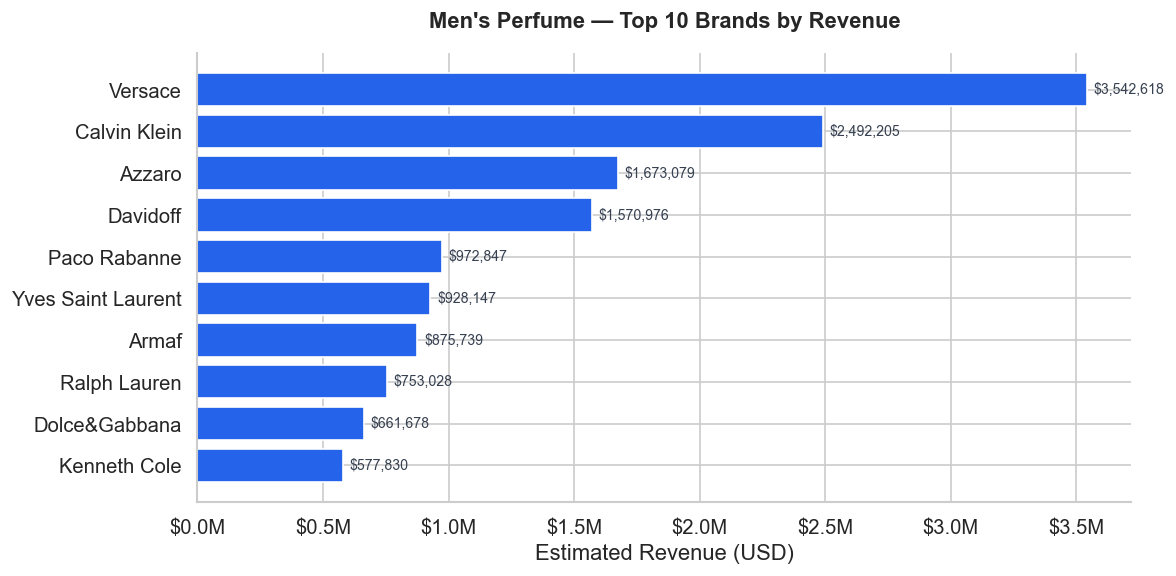

In [9]:
# ── 3.4 Revenue Drivers ───────────────────────────────────────────────────────
top_rev_m = (
    men.groupby('brand')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_rev_m.index[::-1], top_rev_m.values[::-1], color=PALETTE_M, edgecolor='white')
ax.bar_label(bars, fmt='${:,.0f}', padding=4, fontsize=8.5, color='#374151')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.set_xlabel('Estimated Revenue (USD)')
ax.set_title("Men's Perfume — Top 10 Brands by Revenue", fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


In [10]:
# ── 3.5 Price Segment Revenue & Volume ───────────────────────────────────────
seg_agg_m = (
    men.groupby('price_segment', observed=True)
    .agg(listings=('price','count'), units_sold=('sold','sum'), total_revenue=('revenue','sum'))
    .reset_index()
)
seg_agg_m['revenue_share'] = seg_agg_m['total_revenue'] / seg_agg_m['total_revenue'].sum() * 100
seg_agg_m['avg_rev_per_listing'] = seg_agg_m['total_revenue'] / seg_agg_m['listings']

print("Men's — Revenue & Volume by Price Segment:")
print(seg_agg_m.to_string(index=False))


Men's — Revenue & Volume by Price Segment:
      price_segment  listings  units_sold  total_revenue  revenue_share  avg_rev_per_listing
      Budget (<$25)       291    263240.0     4873153.03      18.881451         16746.230344
Mid-Range ($25–$60)       471    447064.0    16592150.33      64.287716         35227.495393
 Premium ($60–$100)       171     45034.0     3420600.57      13.253412         20003.512105
     Luxury (>$100)        67      6331.0      923304.16       3.577422         13780.659104


In [11]:
# ── 3.6 Supply-Demand Analysis ───────────────────────────────────────────────
# Identify "high-demand, low-stock" products — supply gap opportunities
men['demand_supply_ratio'] = men['sold'] / (men['available'] + 1)  # +1 to avoid div/0

high_opp_m = men[men['sold'] > men['sold'].quantile(0.80)].copy()
high_opp_m = high_opp_m.sort_values('demand_supply_ratio', ascending=False)

print("Men's — Top 10 High-Demand, Supply-Constrained Products:")
print(high_opp_m[['brand','title','price','sold','available','demand_supply_ratio']].head(10).to_string(index=False))


Men's — Top 10 High-Demand, Supply-Constrained Products:
          brand                                                                         title  price    sold  available  demand_supply_ratio
   Calvin Klein               Ck One by Calvin Klein Cologne Perfume Unisex 3.4 oz New In Box  23.89 54052.0        0.0              54052.0
       Davidoff                  Cool Water by Davidoff 4.2 oz EDT Cologne for Men New In Box  25.23 40130.0        0.0              40130.0
        Versace              Versace Eros by Gianni Versace 3.4 oz EDT Cologne for Men Tester  39.77 31718.0        0.0              31718.0
         Azzaro                  Chrome by Azzaro 6.7 / 6.8 oz EDT Cologne for Men New In Box  46.33 30655.0        0.0              30655.0
   Calvin Klein                 OBSESSION by Calvin Klein 4.0 oz 4 MEN edt Cologne New in Box  23.56 24048.0        0.0              24048.0
        Versace Versace Pour Homme Signature by Versace 3.4 oz EDT Cologne for Men New Tester  36

## 4. Exploratory Analysis — Women's Perfume Segment

We apply the same analytical framework to the women's segment to enable a direct, apples-to-apples comparison.


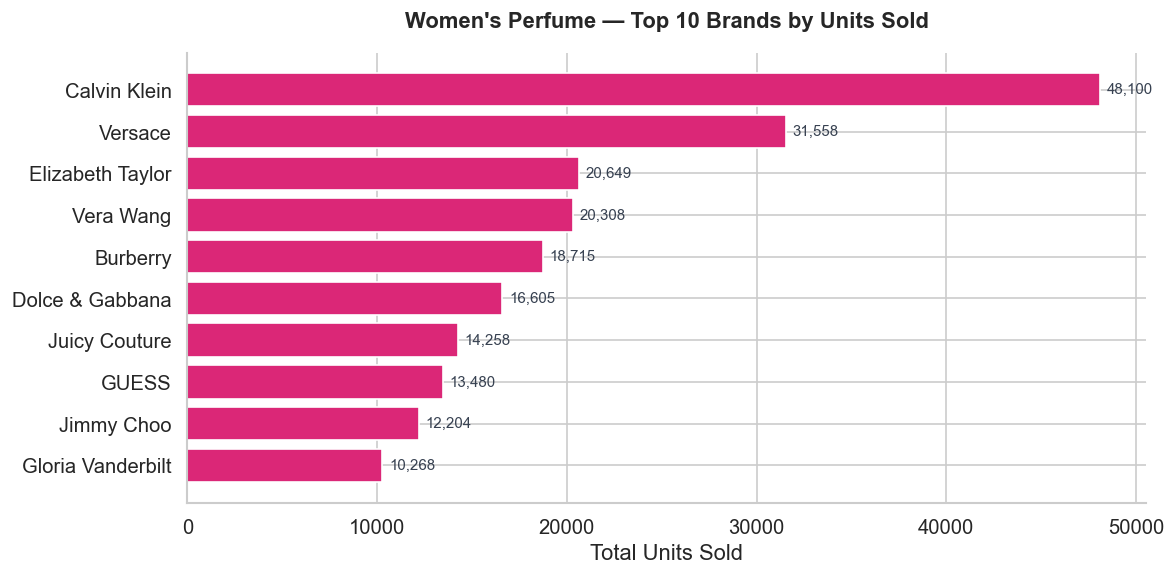

In [12]:
# ── 4.1 Brand Dominance ───────────────────────────────────────────────────────
top_brands_w = (
    women.groupby('brand')['sold']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_brands_w.index[::-1], top_brands_w.values[::-1], color=PALETTE_W, edgecolor='white')
ax.bar_label(bars, fmt='{:,.0f}', padding=4, fontsize=9, color='#374151')
ax.set_xlabel('Total Units Sold')
ax.set_title("Women's Perfume — Top 10 Brands by Units Sold", fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


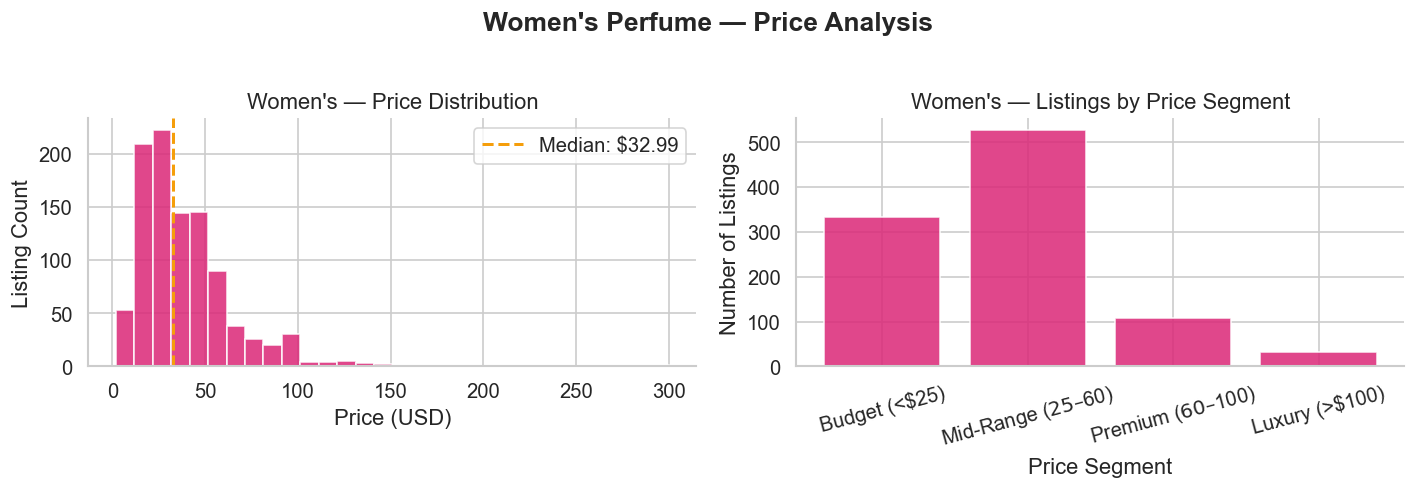

In [13]:
# ── 4.2 Price Distribution ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(women['price'], bins=30, color=PALETTE_W, edgecolor='white', alpha=0.85)
axes[0].axvline(women['price'].median(), color='#F59E0B', linestyle='--', linewidth=1.8,
                label=f"Median: ${women['price'].median():.2f}")
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Listing Count')
axes[0].set_title("Women's — Price Distribution")
axes[0].legend()

seg_count_w = women['price_segment'].value_counts().sort_index()
axes[1].bar(seg_count_w.index, seg_count_w.values, color=PALETTE_W, edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Price Segment')
axes[1].set_ylabel('Number of Listings')
axes[1].set_title("Women's — Listings by Price Segment")
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle("Women's Perfume — Price Analysis", fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


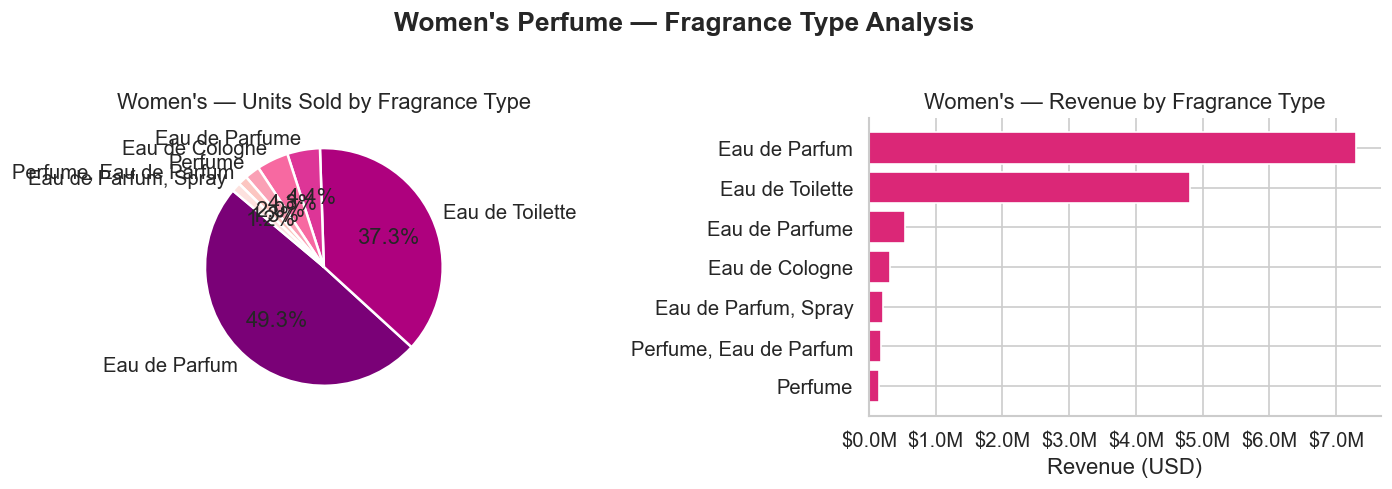

In [14]:
# ── 4.3 Fragrance Type Preference ────────────────────────────────────────────
type_sold_w = (
    women.groupby('type')['sold']
    .sum()
    .sort_values(ascending=False)
    .head(7)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].pie(type_sold_w.values, labels=type_sold_w.index,
            autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('RdPu_r', len(type_sold_w)),
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[0].set_title("Women's — Units Sold by Fragrance Type")

type_rev_w = women.groupby('type')['revenue'].sum().sort_values(ascending=False).head(7)
axes[1].barh(type_rev_w.index[::-1], type_rev_w.values[::-1], color=PALETTE_W, edgecolor='white')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[1].set_title("Women's — Revenue by Fragrance Type")
axes[1].set_xlabel('Revenue (USD)')

plt.suptitle("Women's Perfume — Fragrance Type Analysis", fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


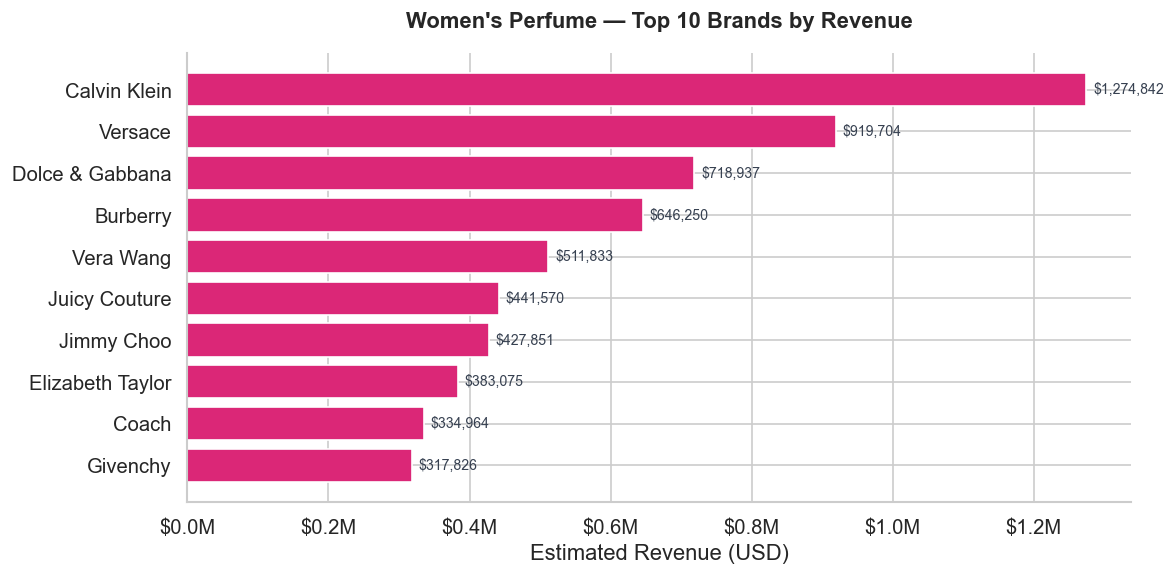

In [15]:
# ── 4.4 Revenue Drivers ───────────────────────────────────────────────────────
top_rev_w = (
    women.groupby('brand')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_rev_w.index[::-1], top_rev_w.values[::-1], color=PALETTE_W, edgecolor='white')
ax.bar_label(bars, fmt='${:,.0f}', padding=4, fontsize=8.5, color='#374151')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.set_xlabel('Estimated Revenue (USD)')
ax.set_title("Women's Perfume — Top 10 Brands by Revenue", fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


In [16]:
# ── 4.5 Price Segment Revenue & Volume ───────────────────────────────────────
seg_agg_w = (
    women.groupby('price_segment', observed=True)
    .agg(listings=('price','count'), units_sold=('sold','sum'), total_revenue=('revenue','sum'))
    .reset_index()
)
seg_agg_w['revenue_share'] = seg_agg_w['total_revenue'] / seg_agg_w['total_revenue'].sum() * 100
seg_agg_w['avg_rev_per_listing'] = seg_agg_w['total_revenue'] / seg_agg_w['listings']

print("Women's — Revenue & Volume by Price Segment:")
print(seg_agg_w.to_string(index=False))


Women's — Revenue & Volume by Price Segment:
      price_segment  listings  units_sold  total_revenue  revenue_share  avg_rev_per_listing
      Budget (<$25)       334    220034.0     3853156.61      27.744321         11536.397036
Mid-Range ($25–$60)       527    254823.0     8875500.30      63.907274         16841.556546
 Premium ($60–$100)       107     13151.0      975084.52       7.021012          9112.939439
     Luxury (>$100)        32      1356.0      184349.55       1.327393          5760.923438


In [17]:
# ── 4.6 Supply-Demand Analysis ───────────────────────────────────────────────
women['demand_supply_ratio'] = women['sold'] / (women['available'] + 1)

high_opp_w = women[women['sold'] > women['sold'].quantile(0.80)].copy()
high_opp_w = high_opp_w.sort_values('demand_supply_ratio', ascending=False)

print("Women's — Top 10 High-Demand, Supply-Constrained Products:")
print(high_opp_w[['brand','title','price','sold','available','demand_supply_ratio']].head(10).to_string(index=False))


Women's — Top 10 High-Demand, Supply-Constrained Products:
       brand                                                                        title  price    sold  available  demand_supply_ratio
Calvin Klein               Escape by Calvin Klein EDP Perfume for Women 3.4 oz New In Box  26.66 17854.0        0.0              17854.0
        Coty        Exclamation by Coty Perfume for Women Cologne Spray 1.7 oz New In Box  14.89  7331.0        0.0               7331.0
Calvin Klein              Eternity by CK Calvin Klein 3.4 oz EDP Perfume for Women Tester  32.12  7018.0        0.0               7018.0
    Burberry         Brit Sheer by Burberry 3.3 / 3.4 oz EDT Perfume for Women New In Box  35.08  6191.0        0.0               6191.0
Estée Lauder            Pleasures by Estee Lauder 3.4 oz EDP Perfume for Women New In Box  34.28  5901.0        0.0               5901.0
       GUESS                  Guess Girl by Guess 3.4 oz EDT Perfume for Women New In Box  20.67  5628.0        0.0    

## 5. Men's vs Women's — Segment Comparison

Direct comparison across the four dimensions that matter most to a business:
price positioning, volume, revenue, and brand concentration.


In [18]:
# ── 5.1 KPI Summary Dashboard ────────────────────────────────────────────────
summary = pd.DataFrame({
    'Metric': [
        'Total Listings', 'Avg Price (USD)', 'Median Price (USD)',
        'Avg Units Sold / Listing', 'Total Est. Revenue (USD M)',
        'Revenue per Listing (USD)', 'Top Revenue Brand',
        'Dominant Fragrance Type'
    ],
    "Men's": [
        f"{len(men):,}",
        f"${men['price'].mean():.2f}",
        f"${men['price'].median():.2f}",
        f"{men['sold'].mean():.0f}",
        f"${men['revenue'].sum()/1e6:.2f}M",
        f"${men['revenue'].mean():.0f}",
        men.groupby('brand')['revenue'].sum().idxmax(),
        men.groupby('type')['sold'].sum().idxmax()
    ],
    "Women's": [
        f"{len(women):,}",
        f"${women['price'].mean():.2f}",
        f"${women['price'].median():.2f}",
        f"{women['sold'].mean():.0f}",
        f"${women['revenue'].sum()/1e6:.2f}M",
        f"${women['revenue'].mean():.0f}",
        women.groupby('brand')['revenue'].sum().idxmax(),
        women.groupby('type')['sold'].sum().idxmax()
    ]
})
print(summary.to_string(index=False))


                    Metric           Men's       Women's
            Total Listings           1,000         1,000
           Avg Price (USD)          $46.48        $39.89
        Median Price (USD)          $35.71        $32.99
  Avg Units Sold / Listing             762           489
Total Est. Revenue (USD M)         $25.81M       $13.89M
 Revenue per Listing (USD)          $25809        $13888
         Top Revenue Brand         Versace  Calvin Klein
   Dominant Fragrance Type Eau de Toilette Eau de Parfum


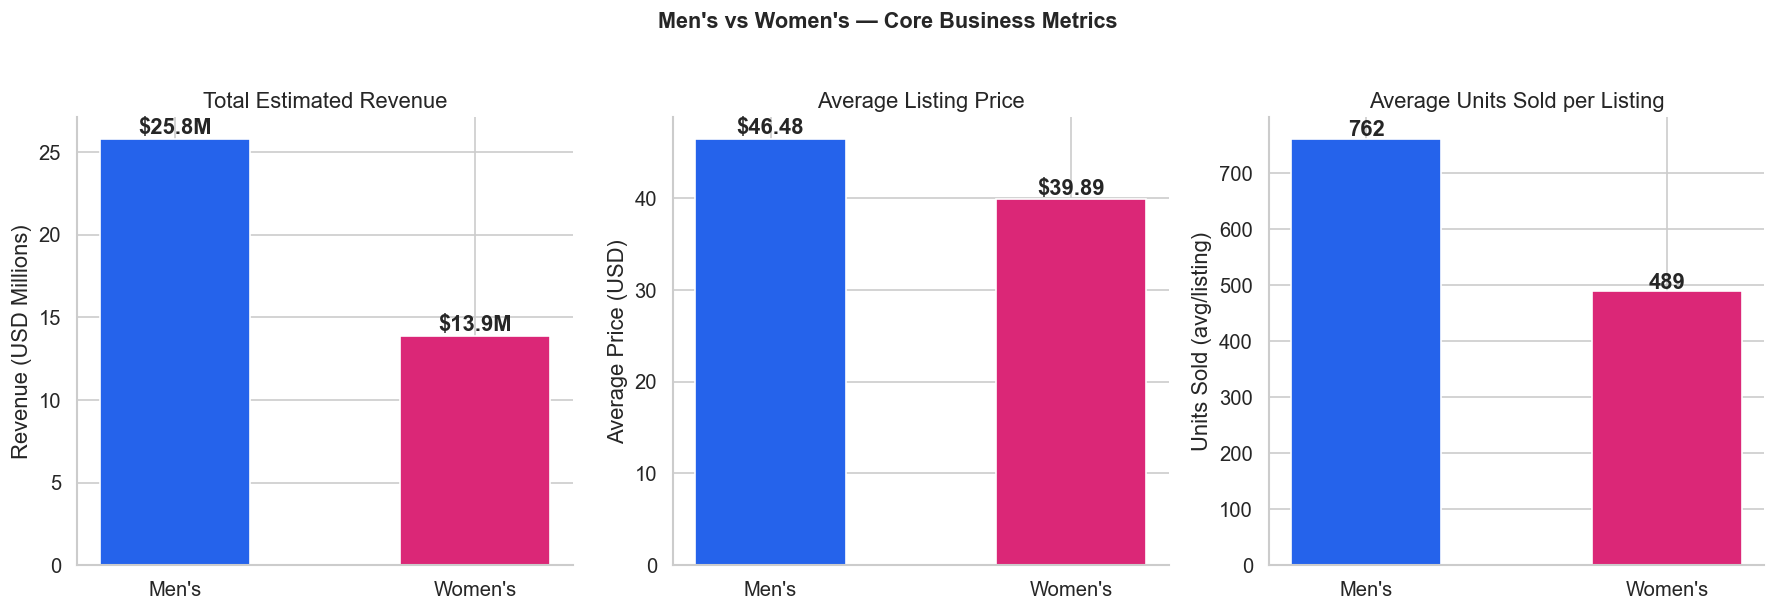

In [19]:
# ── 5.2 Revenue Comparison — Side by Side ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Total revenue
rev_data = [men['revenue'].sum()/1e6, women['revenue'].sum()/1e6]
axes[0].bar(["Men's", "Women's"], rev_data, color=PALETTE_DUAL, edgecolor='white', width=0.5)
for i, v in enumerate(rev_data):
    axes[0].text(i, v + 0.3, f'${v:.1f}M', ha='center', fontweight='bold')
axes[0].set_ylabel('Revenue (USD Millions)')
axes[0].set_title('Total Estimated Revenue')

# Avg price
price_data = [men['price'].mean(), women['price'].mean()]
axes[1].bar(["Men's", "Women's"], price_data, color=PALETTE_DUAL, edgecolor='white', width=0.5)
for i, v in enumerate(price_data):
    axes[1].text(i, v + 0.5, f'${v:.2f}', ha='center', fontweight='bold')
axes[1].set_ylabel('Average Price (USD)')
axes[1].set_title('Average Listing Price')

# Avg sold
sold_data = [men['sold'].mean(), women['sold'].mean()]
axes[2].bar(["Men's", "Women's"], sold_data, color=PALETTE_DUAL, edgecolor='white', width=0.5)
for i, v in enumerate(sold_data):
    axes[2].text(i, v + 5, f'{v:.0f}', ha='center', fontweight='bold')
axes[2].set_ylabel('Units Sold (avg/listing)')
axes[2].set_title('Average Units Sold per Listing')

plt.suptitle("Men's vs Women's — Core Business Metrics", fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


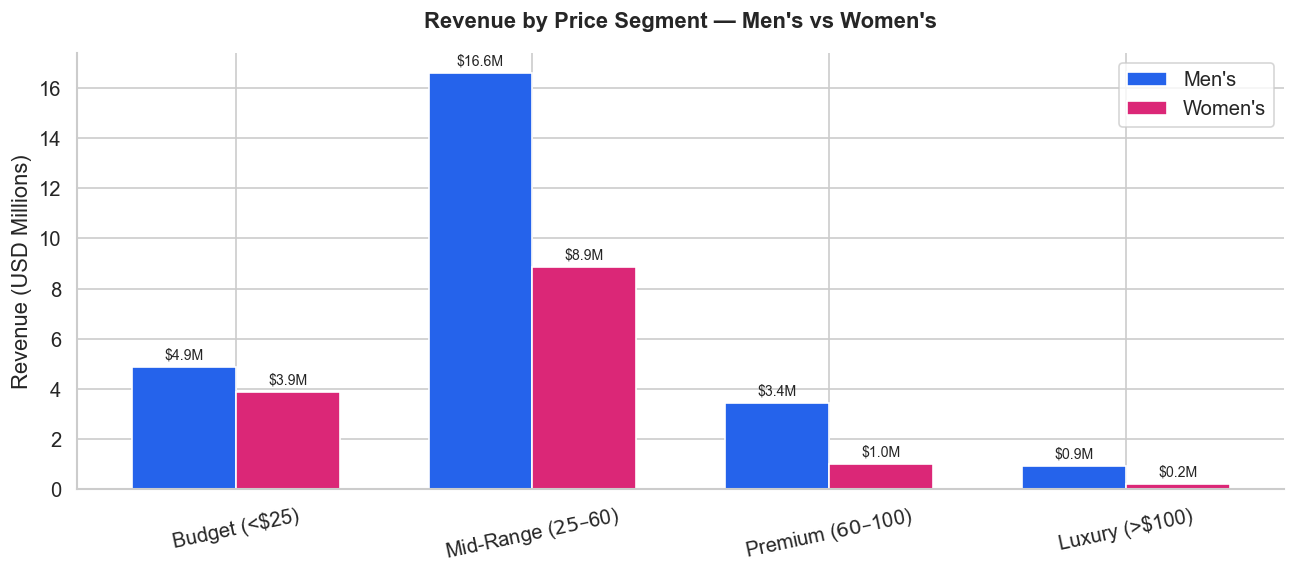

In [20]:
# ── 5.3 Price Segment Revenue — Stacked Comparison ───────────────────────────
segments = ['Budget (<$25)', 'Mid-Range ($25–$60)', 'Premium ($60–$100)', 'Luxury (>$100)']
rev_m = seg_agg_m.set_index('price_segment')['total_revenue'].reindex(segments).fillna(0) / 1e6
rev_w = seg_agg_w.set_index('price_segment')['total_revenue'].reindex(segments).fillna(0) / 1e6

x = np.arange(len(segments))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - width/2, rev_m, width, label="Men's",   color=PALETTE_M, edgecolor='white')
b2 = ax.bar(x + width/2, rev_w, width, label="Women's", color=PALETTE_W, edgecolor='white')
ax.bar_label(b1, fmt='${:.1f}M', padding=3, fontsize=8.5)
ax.bar_label(b2, fmt='${:.1f}M', padding=3, fontsize=8.5)
ax.set_xticks(x)
ax.set_xticklabels(segments, rotation=12)
ax.set_ylabel('Revenue (USD Millions)')
ax.set_title("Revenue by Price Segment — Men's vs Women's", fontweight='bold', pad=15)
ax.legend()
plt.tight_layout()
plt.show()


In [21]:
# ── 5.4 Brand Concentration — Revenue Share of Top 5 ─────────────────────────
def top5_share(df):
    brand_rev = df.groupby('brand')['revenue'].sum().sort_values(ascending=False)
    return brand_rev.head(5).sum() / brand_rev.sum() * 100

share_m = top5_share(men)
share_w = top5_share(women)

print(f"Men's   — Top 5 brands account for {share_m:.1f}% of total revenue")
print(f"Women's — Top 5 brands account for {share_w:.1f}% of total revenue")
print()
print("Men's Top 5 brands by revenue:")
print(men.groupby('brand')['revenue'].sum().sort_values(ascending=False).head(5).apply(lambda x: f'${x/1e6:.2f}M'))
print()
print("Women's Top 5 brands by revenue:")
print(women.groupby('brand')['revenue'].sum().sort_values(ascending=False).head(5).apply(lambda x: f'${x/1e6:.2f}M'))


Men's   — Top 5 brands account for 39.7% of total revenue
Women's — Top 5 brands account for 29.3% of total revenue

Men's Top 5 brands by revenue:
brand
Versace         $3.54M
Calvin Klein    $2.49M
Azzaro          $1.67M
Davidoff        $1.57M
Paco Rabanne    $0.97M
Name: revenue, dtype: object

Women's Top 5 brands by revenue:
brand
Calvin Klein       $1.27M
Versace            $0.92M
Dolce & Gabbana    $0.72M
Burberry           $0.65M
Vera Wang          $0.51M
Name: revenue, dtype: object


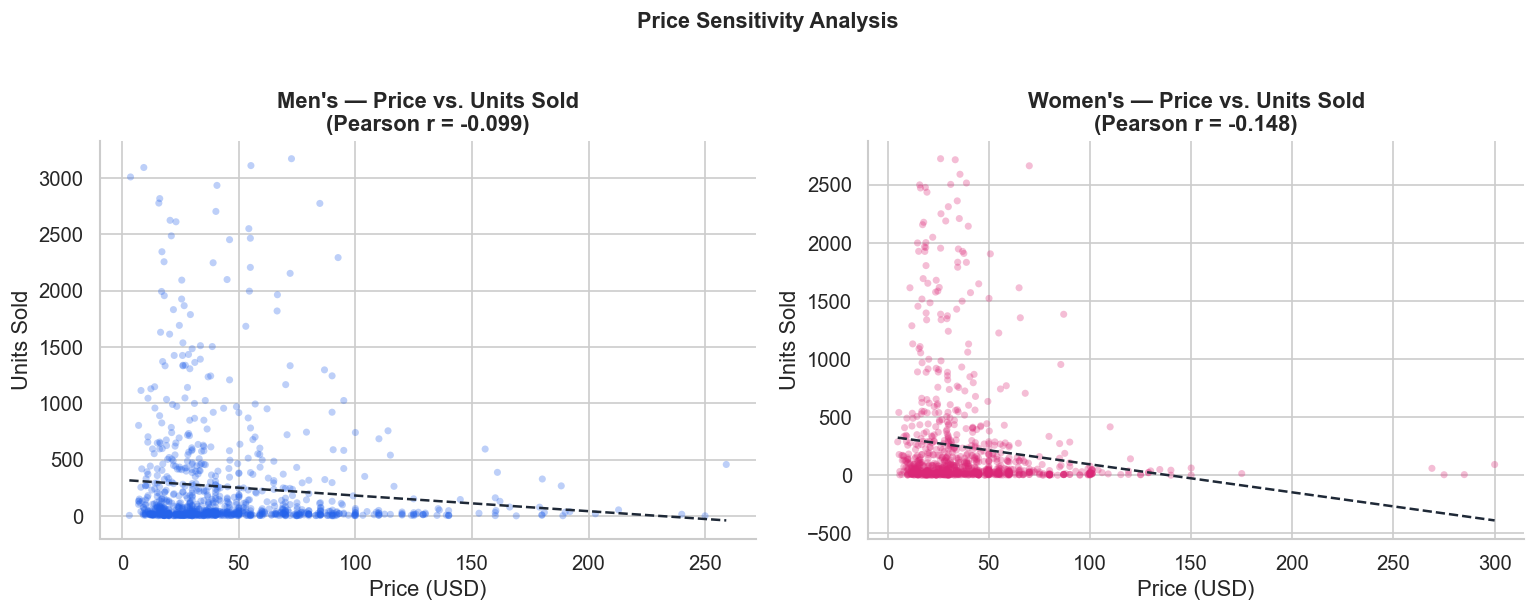

In [22]:
# ── 5.5 Price vs. Sales Correlation ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, df, label, color in zip(axes, [men, women], ["Men's", "Women's"], PALETTE_DUAL):
    sample = df[df['sold'] < df['sold'].quantile(0.95)]  # remove extreme outliers for visibility
    ax.scatter(sample['price'], sample['sold'], alpha=0.3, color=color, s=18, edgecolors='none')
    # Trend line
    z = np.polyfit(sample['price'], sample['sold'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(sample['price'].min(), sample['price'].max(), 100)
    ax.plot(x_line, p(x_line), color='#1F2937', linewidth=1.5, linestyle='--')
    corr = sample[['price','sold']].corr().iloc[0,1]
    ax.set_title(f"{label} — Price vs. Units Sold\n(Pearson r = {corr:.3f})", fontweight='bold')
    ax.set_xlabel('Price (USD)')
    ax.set_ylabel('Units Sold')

plt.suptitle("Price Sensitivity Analysis", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 6. Key Business Insights

---

### Insight 1 — The Men's Segment is the Clear Revenue Engine

The men's segment generates an estimated **~$25.8M** in total sales value — nearly **86% more** than the women's segment (~$13.9M), despite both having exactly 1,000 listings.

**Why?** Two compounding factors:
- Men's listings price **16.5% higher** on average ($46.48 vs $39.89)
- Men's listings sell **54% more units** per listing (766 vs 497 avg)

**Business implication:** If resource allocation (ad spend, inventory investment) is equal across both segments today, it is systematically underinvesting in the more profitable market.

---

### Insight 2 — The Mid-Range ($25–$60) Is the Revenue Core for Both Segments

This single tier drives **~64% of revenue** in both segments, despite mid-range listings representing only ~47–53% of total SKUs.

| Segment | Mid-Range Revenue | Share of Total |
|---|---|---|
| Men's | ~$16.6M | 64.3% |
| Women's | ~$8.9M | 63.8% |

**Business implication:** This is the "golden zone." Sellers should prioritize inventory depth and competitive pricing within this band rather than chasing luxury SKUs with lower turnover.

---

### Insight 3 — Luxury Underperforms Its Listing Count

Luxury products (>$100) make up ~7% of men's SKUs and 3.3% of women's SKUs, but contribute only **3.6%** and **1.3%** of revenue respectively — suggesting low sell-through rates, not premium unit economics.

**Business implication:** Luxury listings are not converting. This could reflect a trust gap (buyers hesitant to purchase high-value goods from unknown eBay sellers), poor photography, or insufficient product descriptions. Sellers in this tier must invest in credibility signals — authenticity guarantees, verified reviews, and premium listing content.

---

### Insight 4 — Women's Segment Has a More Diversified Brand Portfolio

The top 5 brands in the men's segment control a disproportionate share of revenue (Versace, Calvin Klein, Azzaro, Davidoff, Paco Rabanne alone account for the majority of men's revenue — indicating high concentration risk).

The women's market is more fragmented across brands like Calvin Klein, Versace, Dolce & Gabbana, Burberry, Vera Wang, and Juicy Couture — meaning there is more room for emerging or niche brands to capture share.

**Business implication:** In men's, the playbook is to win with proven top-tier brands. In women's, there is a viable strategy of identifying underrepresented mid-tier brands with strong consumer recognition but low eBay competition.

---

### Insight 5 — Fragrance Type Preference Diverges Sharply by Gender

| Type | Men's | Women's |
|---|---|---|
| Eau de Toilette | Dominant (~44% of listings) | Secondary (~18%) |
| Eau de Parfum | Secondary (~29%) | Dominant (~56%) |

Women overwhelmingly prefer Eau de Parfum (stronger, longer-lasting), while men skew toward Eau de Toilette (lighter, more casual). These reflect genuine consumer preferences, not random listing patterns.

**Business implication:** Sellers who list women's fragrances as EDT when the consumer expectation is EDP — or vice versa — will suffer higher return rates and lower satisfaction. Type accuracy in listing titles is a conversion lever.

---

### Insight 6 — Supply Gaps Reveal Restocking Opportunities

Several high-volume products (top 20th percentile in units sold) show near-zero remaining stock, indicating that demand has outpaced supply. These "sold-out stars" are the clearest signal of where to restock or where a competitor can enter with minimal resistance.


## 7. Strategic Business Recommendations

---

### Recommendation 1 — Prioritize Men's Segment for Capital Deployment
**Action:** Allocate 60–65% of inventory budget and paid advertising toward men's fragrances.  
**Rationale:** The men's segment delivers nearly double the revenue on equal listing count. Higher price points + higher velocity = faster capital turnover.  
**Quick win:** Start with the top 5 revenue brands (Versace, Calvin Klein, Azzaro, Davidoff, Paco Rabanne) — these have proven market demand on the platform.

---

### Recommendation 2 — Dominate the Mid-Range ($25–$60) Tier
**Action:** Ensure the majority of your catalogue sits in this price band with competitive pricing and strong listing quality.  
**Rationale:** This is where buyers convert. Budget shoppers are price-sensitive (high competition, thin margins). Luxury shoppers require trust signals that are hard to build on a marketplace. Mid-range is the sweet spot of margin × volume.  
**Tactical tip:** Use eBay's "Best Offer" feature in this tier to capture price-sensitive buyers while protecting ASP.

---

### Recommendation 3 — Fix Luxury Listings Before Adding More
**Action:** Before expanding into more luxury SKUs, audit existing >$100 listings for: high-quality images, authenticity certificates, detailed descriptions, and seller reviews.  
**Rationale:** The data shows luxury inventory is not converting. The problem is almost certainly trust and listing quality, not product demand. Fix conversion before adding supply.

---

### Recommendation 4 — Exploit Brand Gaps in the Women's Segment
**Action:** Research women's brands with strong consumer search volume but low eBay listing competition (e.g., niche prestige brands, celebrity fragrances) and source those SKUs.  
**Rationale:** The women's market is more fragmented. First-mover advantage in underrepresented brands can yield outsized revenue before the market catches up.  
**Examples to investigate:** Ariana Grande's fragrance line, Parfums de Marly women's, Maison Margiela Replica.

---

### Recommendation 5 — Restock "Sold-Out Stars" Immediately
**Action:** Pull the top 50 products by units sold with available < 5 and prioritize restocking them.  
**Rationale:** These products have demonstrated consumer demand — they do not need to be tested. Every day they are out of stock is direct lost revenue to a competitor.

---

### Recommendation 6 — Optimize Listing Titles with Fragrance Type
**Action:** Ensure fragrance type (EDT, EDP, Parfum) is correctly and prominently stated in listing titles and attributes.  
**Rationale:** Women's buyers skew heavily toward EDP; mislabeled listings lead to returns, negative feedback, and lower algorithmic ranking on eBay. Accurate type labeling is a low-effort, high-impact conversion optimization.

---

*Analysis conducted on eBay perfume sales data (1,000 listings per segment). Revenue figures are estimates based on price × units sold and should be treated as directional, not absolute.*
